In [1]:
# ============================================================
# Experiment 8
# Perform Analysis of Variance (ANOVA) on Iris Dataset
# ============================================================


In [2]:
# 1. Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd


In [3]:
# ============================================================
# 2. Load Iris Dataset
# ============================================================


In [4]:
iris = load_iris()

# Create DataFrame
df = pd.DataFrame(
    iris.data,
    columns=[
        "sepal_length",
        "sepal_width",
        "petal_length",
        "petal_width"
    ]
)

# Add target/species column
df["target"] = iris.target

# Convert numerical target into species names
df["species"] = df["target"].map({
    0: "Setosa",
    1: "Versicolor",
    2: "Virginica"
})


In [5]:
# ============================================================
# 3. Display Dataset
# ============================================================


In [6]:
print("First 5 records:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nDataset Information:")
print(df.info())

print("\nStatistical Description:")
print(df.describe())


First 5 records:
   sepal_length  sepal_width  petal_length  petal_width  target species
0           5.1          3.5           1.4          0.2       0  Setosa
1           4.9          3.0           1.4          0.2       0  Setosa
2           4.7          3.2           1.3          0.2       0  Setosa
3           4.6          3.1           1.5          0.2       0  Setosa
4           5.0          3.6           1.4          0.2       0  Setosa

Dataset Shape:
(150, 6)

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   target        150 non-null    int32  
 5   species       150 non-null    str    
dtypes: float64(4), int32(1), str(1)
memory usage: 7.8 KB
None

Sta

In [7]:
# ============================================================
# 4. Visualize Iris Dataset
# ============================================================


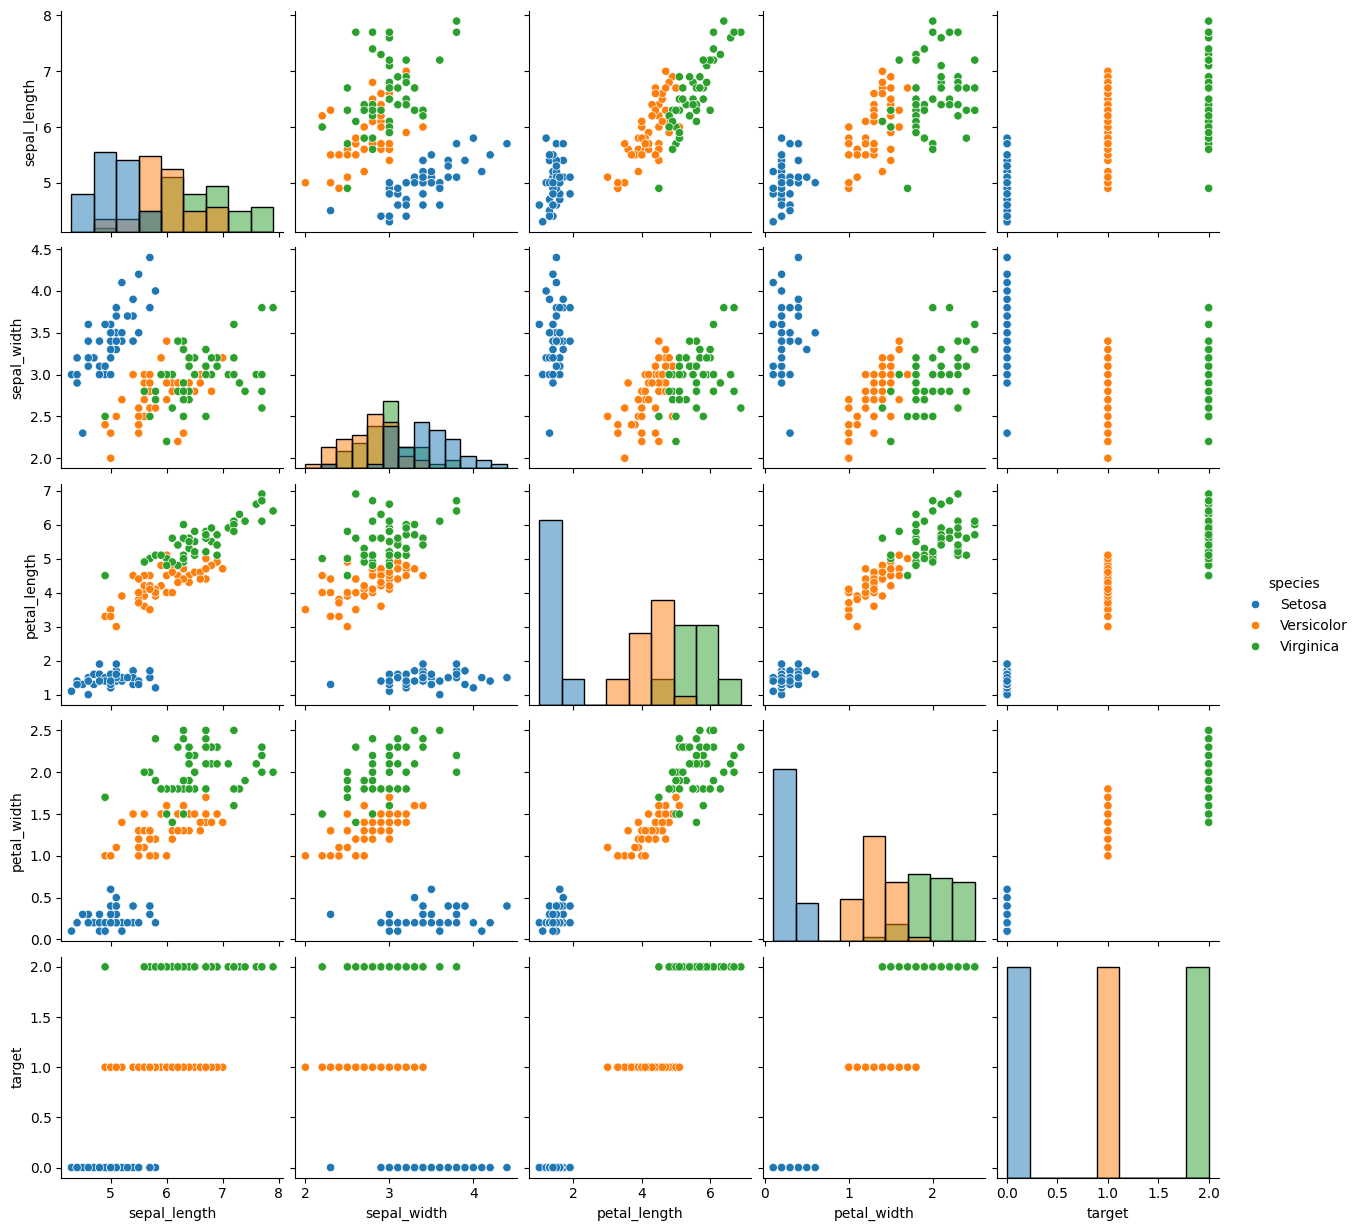

In [8]:
sns.pairplot(
    df,
    hue="species",
    diag_kind="hist"
)

plt.show()



In [9]:
# ============================================================
# 5. Calculate Mean Sepal Width for Each Species
# ============================================================


In [10]:
print("\nMean Sepal Width by Species:")

mean_values = df.groupby("species")["sepal_width"].mean()

print(mean_values)



Mean Sepal Width by Species:
species
Setosa        3.428
Versicolor    2.770
Virginica     2.974
Name: sepal_width, dtype: float64


In [11]:
# ============================================================
# 6. Check Normality using Shapiro-Wilk Test
# ============================================================


In [12]:
print("\nShapiro-Wilk Normality Test:")

for species in df["species"].unique():

    data = df[df["species"] == species]["sepal_width"]

    statistic, p_value = stats.shapiro(data)

    print(
        f"{species}: "
        f"Statistic = {statistic:.4f}, "
        f"P-value = {p_value:.4f}"
    )



Shapiro-Wilk Normality Test:
Setosa: Statistic = 0.9717, P-value = 0.2715
Versicolor: Statistic = 0.9741, P-value = 0.3380
Virginica: Statistic = 0.9674, P-value = 0.1809


In [13]:
# ============================================================
# 7. Check Equality of Variances using Levene's Test
# ============================================================

setosa = df[df["species"] == "Setosa"]["sepal_width"]

versicolor = df[df["species"] == "Versicolor"]["sepal_width"]

virginica = df[df["species"] == "Virginica"]["sepal_width"]


levene_stat, levene_p = stats.levene(
    setosa,
    versicolor,
    virginica
)

print("\nLevene's Test:")
print("Statistic =", levene_stat)
print("P-value =", levene_p)



Levene's Test:
Statistic = 0.5902115655853319
P-value = 0.5555178984739078


In [14]:
# ============================================================
# 8. Perform One-Way ANOVA
# ============================================================


In [15]:
f_value, p_value = stats.f_oneway(
    setosa,
    versicolor,
    virginica
)

print("\nOne-Way ANOVA Results:")
print("F-value =", f_value)
print("P-value =", p_value)




One-Way ANOVA Results:
F-value = 49.160040089612075
P-value = 4.49201713330911e-17


In [17]:

# ============================================================
# 9. Interpret ANOVA Result
# ============================================================

alpha = 0.05

print("\nANOVA Interpretation:")

if p_value < alpha:
    print("Reject the Null Hypothesis.")
    print("There is a statistically significant difference between the mean sepal widths of the three species."
    )
else:
    print("Fail to Reject the Null Hypothesis.")
    print("There is no statistically significant difference between the mean sepal widths of the three species."
    )





ANOVA Interpretation:
Reject the Null Hypothesis.
There is a statistically significant difference between the mean sepal widths of the three species.


In [18]:
# ============================================================
# 10. Tukey HSD Post-Hoc Test
# ============================================================



Tukey HSD Post-Hoc Test:
    Multiple Comparison of Means - Tukey HSD, FWER=0.05     
  group1     group2   meandiff p-adj   lower   upper  reject
------------------------------------------------------------
    Setosa Versicolor   -0.658    0.0 -0.8189 -0.4971   True
    Setosa  Virginica   -0.454    0.0 -0.6149 -0.2931   True
Versicolor  Virginica    0.204 0.0088  0.0431  0.3649   True
------------------------------------------------------------


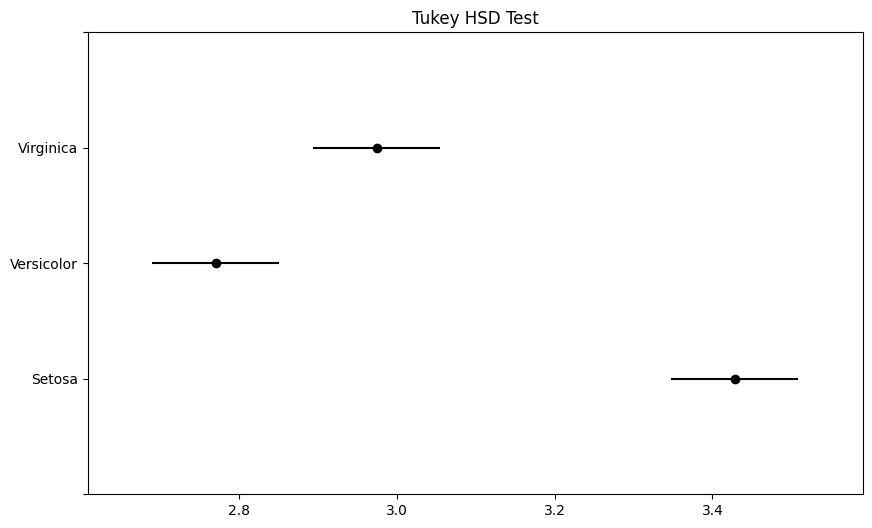

In [19]:
if p_value < alpha:

    tukey = pairwise_tukeyhsd(
        endog=df["sepal_width"],
        groups=df["species"],
        alpha=0.05
    )

    print("\nTukey HSD Post-Hoc Test:")
    print(tukey)

    # Display Tukey plot
    tukey.plot_simultaneous()
    plt.title("Tukey HSD Test")
    plt.show()
